# Trabalho Prático 2: Aprendizado de Máquina (QSAR Biodegradation)
**Objetivo:** Prever a biodegradabilidade de substâncias químicas (RB vs NRB).
**Pipeline de Pré-processamento Avançado:**
1. Divisão Estratificada Imediata (70/15/15) para evitar *Data Leakage*.
2. Seleção de Features (Top 20) com Random Forest.
3. Tratamento Multivariado de Outliers com Isolation Forest (apenas no Treino).
4. Normalização Estatística (Z-Score).
5. Balanceamento de Classes com SMOTE (apenas no Treino).

In [ ]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Divisão
from sklearn.model_selection import train_test_split, PredefinedSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from imblearn.over_sampling import SMOTE

# Modelos Supervisionados
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Métricas de Avaliação
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 1. Carregamento, Limpeza Básica e Divisão Imediata
Para garantir a integridade do protocolo experimental, dividimos os dados em Treino (70%), Validação (15%) e Teste (15%) antes de aplicar qualquer técnica de redução ou tratamento de outliers.

In [ ]:
# Carregamento e remoção de duplicatas/nulos
df_raw = pd.read_csv('biodeg_normalizado.csv').drop_duplicates().dropna()

# Separação de Features e Target
target_col = 'experimental class'
X_raw = df_raw.drop(columns=[target_col])
y_raw = df_raw[target_col]

# Codificação da Variável Alvo
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
print(f"Mapeamento do Target: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# Divisão: 30% para Temp (que será Validação e Teste) e 70% para Treino
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_encoded, test_size=0.30, stratify=y_encoded, random_state=42
)

# Divisão: 50% do Temp para Validação (15% do total) e 50% para Teste (15% do total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras | Validação: {X_val.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Mapeamento do Target: {'NRB': np.int64(0), 'RB': np.int64(1)}
Treino: 736 amostras | Validação: 158 amostras | Teste: 158 amostras


---
## 0. Análise Exploratória dos Dados (EDA)
Antes de qualquer pré-processamento, investigamos a estrutura do dataset para embasar nossas decisões: distribuição do alvo, correlações entre features e distribuição das variáveis mais relevantes.

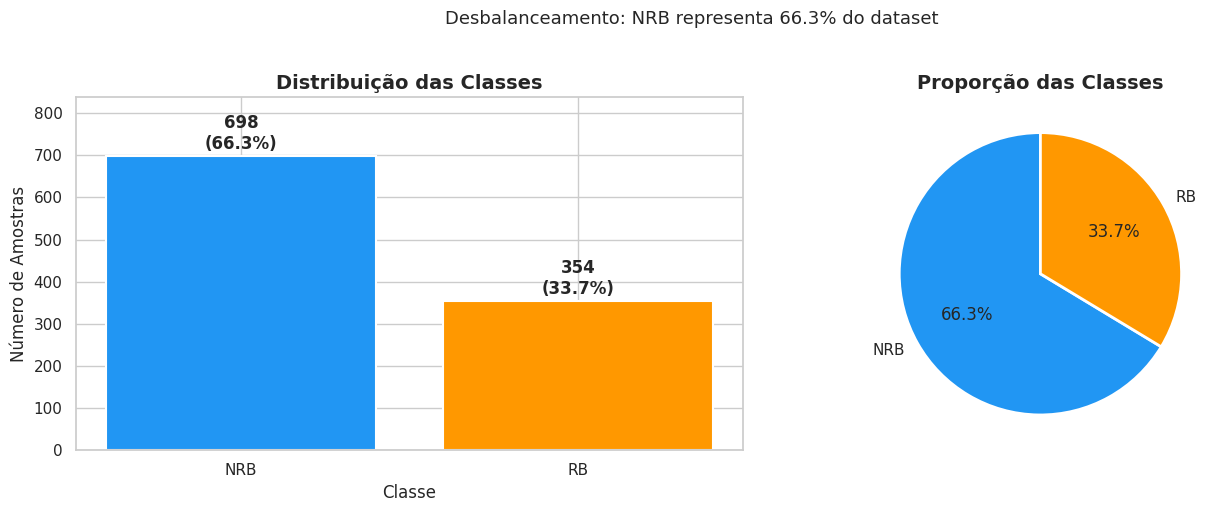

Razão NRB/RB: 1.97x — desbalanceamento moderado, justificando o uso de SMOTE.


In [ ]:
# ── EDA: Distribuição das Classes ────────────────────────────────────────────
contagem = df_raw['experimental class'].value_counts()
percentuais = df_raw['experimental class'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
bars = axes[0].bar(contagem.index, contagem.values,
                   color=['#2196F3', '#FF9800'], edgecolor='white', linewidth=1.5)
for bar, val, pct in zip(bars, contagem.values, percentuais.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 8, f'{val}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Distribuição das Classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Número de Amostras')
axes[0].set_ylim(0, max(contagem.values) * 1.2)

# Pizza
axes[1].pie(contagem.values, labels=contagem.index,
            autopct='%1.1f%%', colors=['#2196F3', '#FF9800'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das Classes', fontsize=14, fontweight='bold')

plt.suptitle('Desbalanceamento: NRB representa 66.3% do dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Razão NRB/RB: {contagem['NRB']/contagem['RB']:.2f}x — desbalanceamento moderado, justificando o uso de SMOTE.")

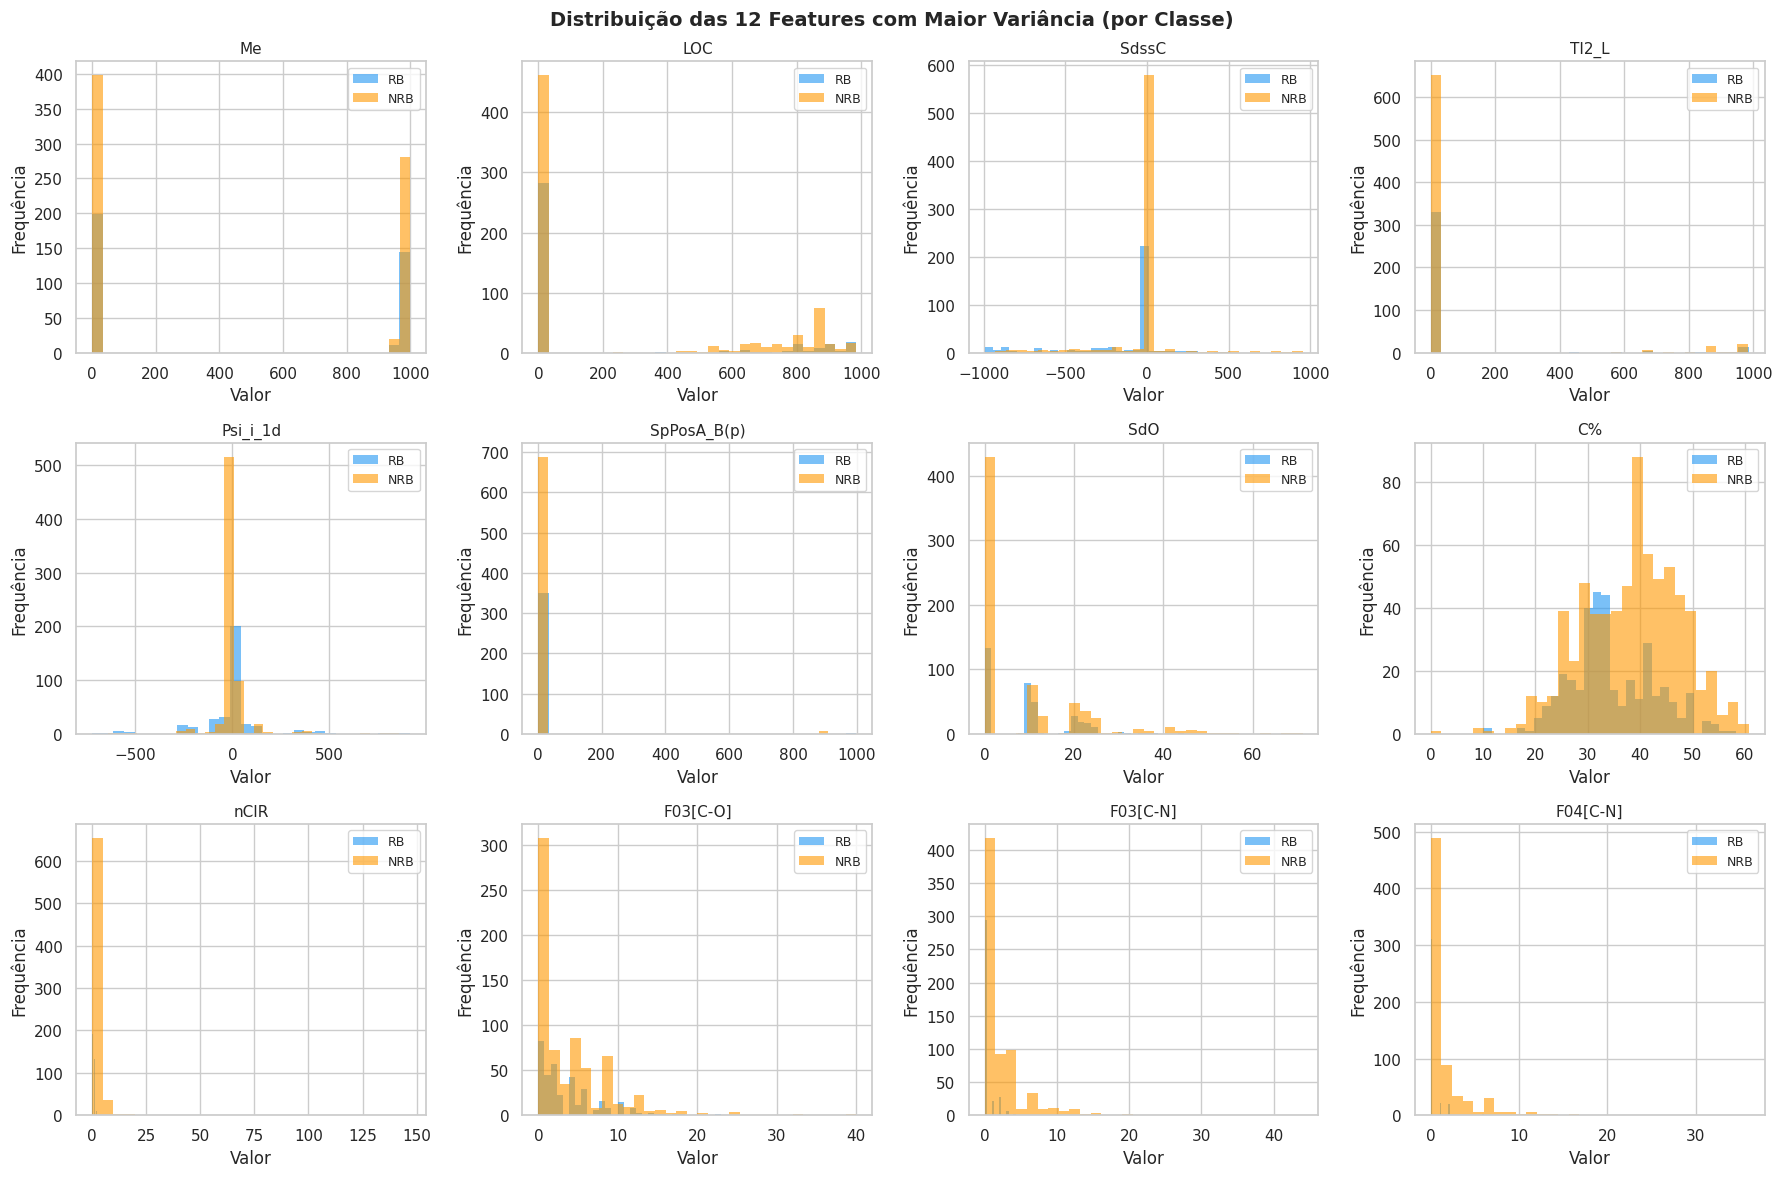

In [ ]:
# ── EDA: Distribuição das Features (Top 12 por variância) ───────────────────
X_eda = df_raw.drop(columns=['experimental class'])
y_eda = df_raw['experimental class']

top12_var = X_eda.var().nlargest(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(top12_var):
    for classe, cor in zip(['RB', 'NRB'], ['#2196F3', '#FF9800']):
        axes[i].hist(df_raw[df_raw['experimental class'] == classe][feat],
                     bins=30, alpha=0.6, label=classe, color=cor, edgecolor='none')
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribuição das 12 Features com Maior Variância (por Classe)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

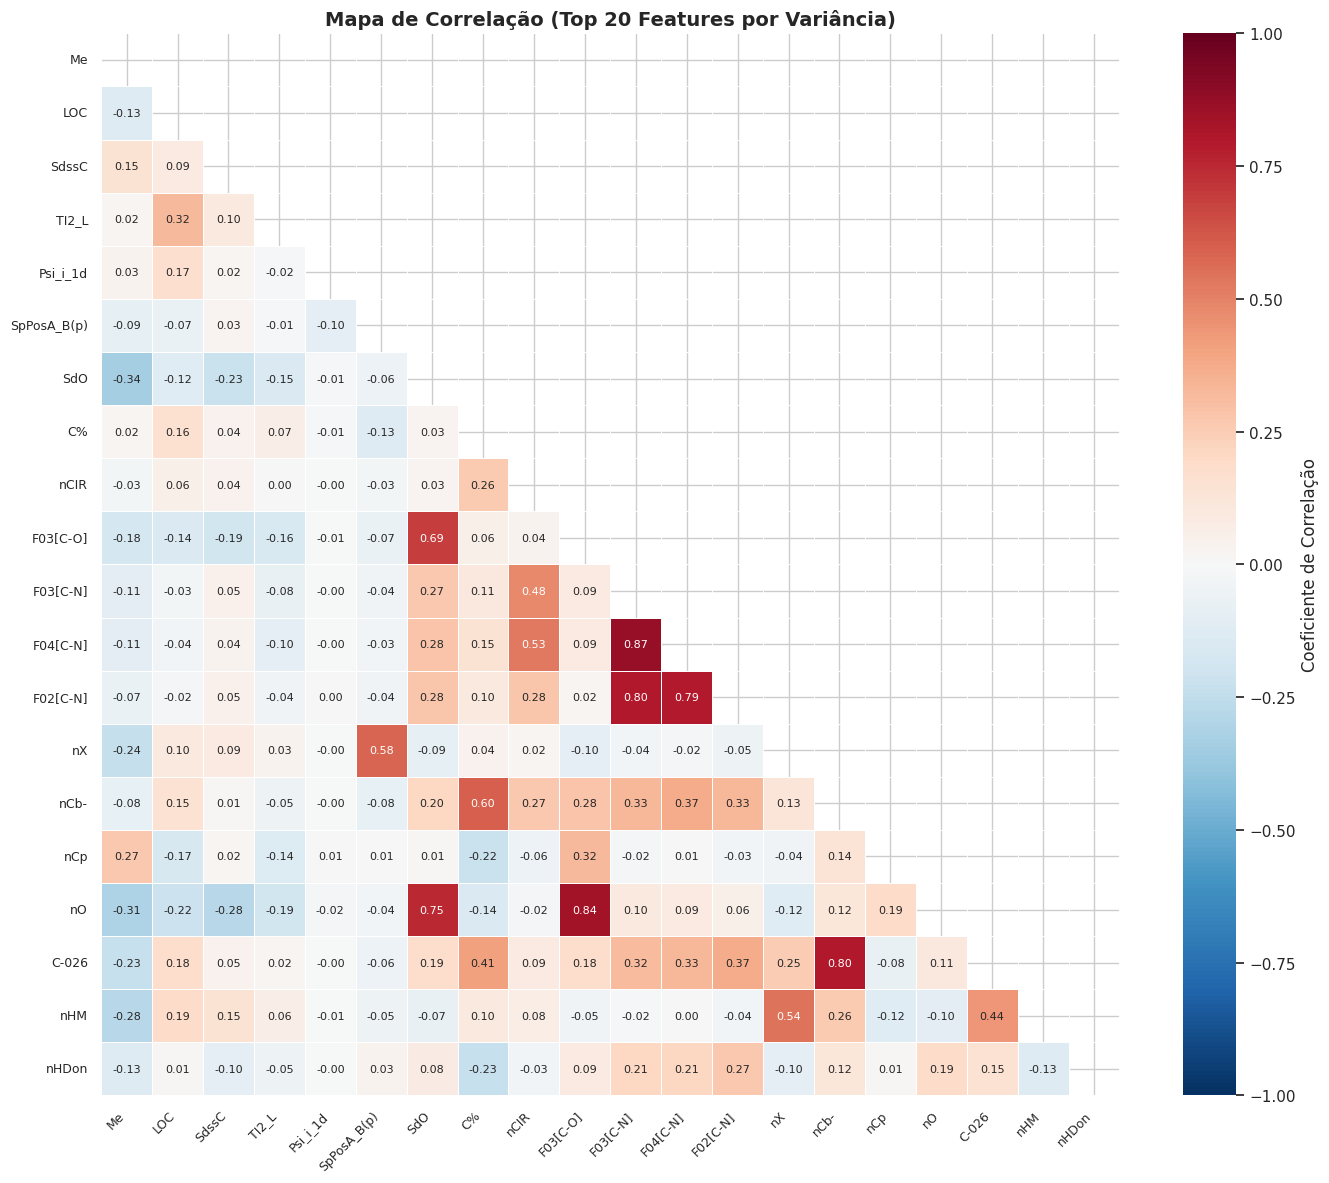

Pares com correlação |r| > 0.8 (possível redundância):
  F03[C-N] × F04[C-N]: 0.870
  F03[C-O] × nO: 0.841
  F02[C-N] × F03[C-N]: 0.804
  C-026 × nCb-: 0.800


In [ ]:
# ── EDA: Mapa de Correlação ──────────────────────────────────────────────────
# Usamos as 20 features de maior variância para legibilidade
top20_var = X_eda.var().nlargest(20).index.tolist()
corr_matrix = X_eda[top20_var].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, annot_kws={'size': 8},
            cbar_kws={'label': 'Coeficiente de Correlação'})
plt.title('Mapa de Correlação (Top 20 Features por Variância)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Pares com correlação alta
corr_abs = corr_matrix.abs()
np.fill_diagonal(corr_abs.values, 0)
high_corr = [(r, c, corr_matrix.loc[r, c])
             for r in corr_abs.index for c in corr_abs.columns
             if corr_abs.loc[r, c] > 0.8 and r < c]
if high_corr:
    print("Pares com correlação |r| > 0.8 (possível redundância):")
    for r, c, val in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f"  {r} × {c}: {val:.3f}")
else:
    print("Nenhum par com correlação |r| > 0.8 encontrado nas top 20 features.")

## 2. Seleção de Features (Redução de Dimensionalidade)
Utilizamos uma Random Forest apenas nos dados de treino para identificar as 20 características moleculares mais importantes, aplicando o Princípio da Parcimônia e reduzindo o ruído do dataset.

--- Extraindo as 20 Features mais importantes ---


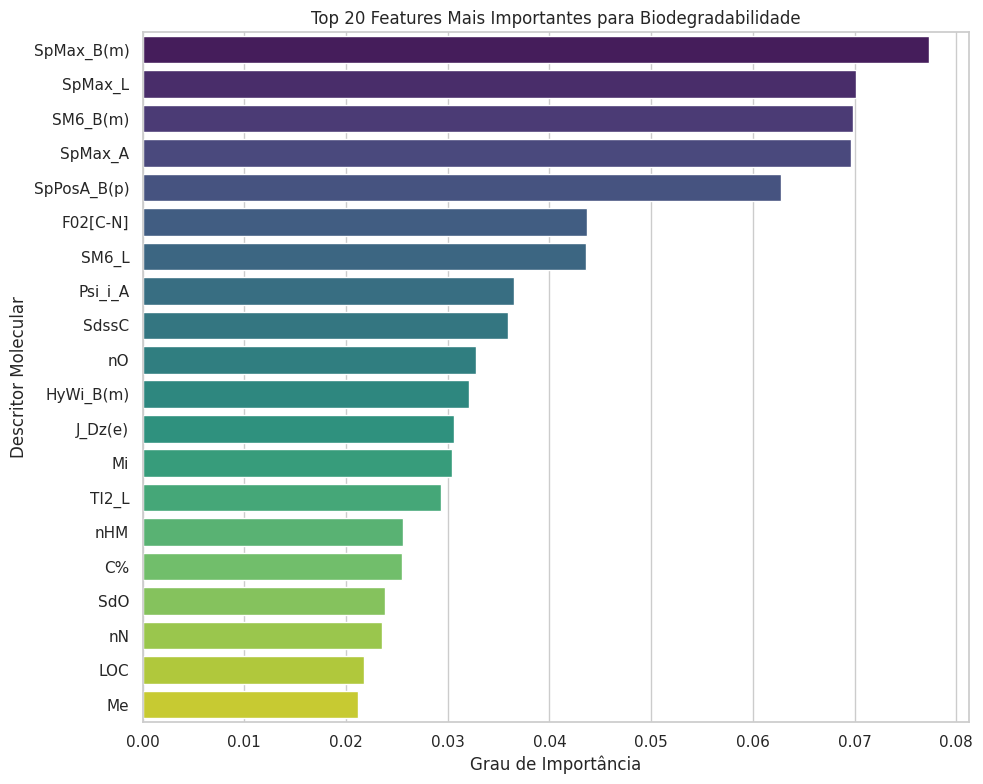

Dimensões reduzidas para 20 features com sucesso!


In [ ]:
print("--- Extraindo as 20 Features mais importantes ---")
# Treinamos a Random Forest (com class_weight para não ignorar a classe menor)
rf_selector = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_selector.fit(X_train, y_train)

# Coletando a importância
importancias = pd.DataFrame({'Feature': X_train.columns, 'Imp': rf_selector.feature_importances_})
importancias = importancias.sort_values(by='Imp', ascending=False)
top_20 = importancias.head(20)['Feature'].tolist()

# Gráfico para o Relatório
plt.figure(figsize=(10, 8))
sns.barplot(x='Imp', y='Feature', data=importancias.head(20), palette='viridis')
plt.title('Top 20 Features Mais Importantes para Biodegradabilidade')
plt.xlabel('Grau de Importância')
plt.ylabel('Descritor Molecular')
plt.tight_layout()
plt.show()

# Reduzimos todas as partições para as 20 colunas selecionadas
X_train_20 = X_train[top_20]
X_val_20 = X_val[top_20]
X_test_20 = X_test[top_20]
print("Dimensões reduzidas para 20 features com sucesso!")

## 3. Remoção de Outliers Multivariada (Isolation Forest)
Removeremos anomalias globais (5% mais extremos) **apenas no conjunto de treinamento**, preservando o conjunto de Teste como uma representação fiel das incertezas do mundo real.

In [ ]:
print("--- Removendo Outliers (Isolation Forest) do Treino ---")
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
outlier_labels = iso_forest.fit_predict(X_train_20)

mask_inliers = (outlier_labels == 1)
X_train_clean = X_train_20[mask_inliers]
y_train_clean = y_train[mask_inliers]

print(f"Amostras removidas (anomalias): {len(y_train) - len(y_train_clean)}")
print(f"Novo tamanho do conjunto de treino: {X_train_clean.shape[0]} amostras")

--- Removendo Outliers (Isolation Forest) do Treino ---
Amostras removidas (anomalias): 37
Novo tamanho do conjunto de treino: 699 amostras


## 4. Normalização (Z-Score) e Balanceamento (SMOTE)
Com os dados de treino limpos, calculamos a média e o desvio padrão para normalizar todos os conjuntos. Em seguida, aplicamos o SMOTE no Treino para balancear as classes (50/50).

In [ ]:
print("--- Normalizando os dados (Z-Score) ---")
scaler = StandardScaler()

# O fit (aprendizado) ocorre APENAS no Treino limpo
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_clean), columns=top_20)

# O transform é aplicado passivamente na Validação e Teste
X_val_scaled = pd.DataFrame(scaler.transform(X_val_20), columns=top_20)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_20), columns=top_20)

print("--- Aplicando SMOTE no Treino ---")
smote = SMOTE(random_state=42)
X_train_final, y_train_final = smote.fit_resample(X_train_scaled, y_train_clean)
print(f"Novo tamanho do Treino após SMOTE: {X_train_final.shape[0]} amostras (Balanceado)")

--- Normalizando os dados (Z-Score) ---
--- Aplicando SMOTE no Treino ---
Novo tamanho do Treino após SMOTE: 918 amostras (Balanceado)


## 5. Configuração da Avaliação e Modelagem Supervisionada
Usaremos o `PredefinedSplit` para forçar o `GridSearchCV` a validar as métricas de hiperparâmetros estritamente nos nossos 15% de Validação estáticos.

In [ ]:
# Preparação do PredefinedSplit
X_train_val = pd.concat([X_train_final, X_val_scaled], axis=0)
y_train_val = np.concatenate([y_train_final, y_val])

test_fold = np.zeros(X_train_val.shape[0])
test_fold[:X_train_final.shape[0]] = -1
ps = PredefinedSplit(test_fold)

# Dicionário de resultados e Função de Avaliação
resultados_modelos = {}

def avaliar_modelo(nome, modelo, params):
    print(f"\n{'='*60}\n--- Treinando e Otimizando: {nome} ---\n{'='*60}")
    grid = GridSearchCV(modelo, params, cv=ps, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_val, y_train_val)

    best_model = grid.best_estimator_
    print(f"Melhores Hiperparâmetros: {grid.best_params_}")

    # Avaliação Final no Conjunto de Teste Intocado
    y_pred = best_model.predict(X_test_scaled)

    # Exibição dos Relatórios
    print("\nRelatório de Classificação no Conjunto de TESTE:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Matriz de Confusão - {nome}')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Predita')
    plt.show()
    return best_model

## 6. Treinamento dos Modelos
Execução da Árvore de Decisão, K-Nearest Neighbors (KNN) e Rede Neural Artificial (MLP) com otimização dos melhores hiperparâmetros baseados na redução de features e tratamento de anomalias.


--- Treinando e Otimizando: Decision Tree ---
Melhores Hiperparâmetros: {'class_weight': None, 'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 2}

Relatório de Classificação no Conjunto de TESTE:
              precision    recall  f1-score   support

         NRB       0.84      0.87      0.85       105
          RB       0.72      0.68      0.70        53

    accuracy                           0.80       158
   macro avg       0.78      0.77      0.78       158
weighted avg       0.80      0.80      0.80       158



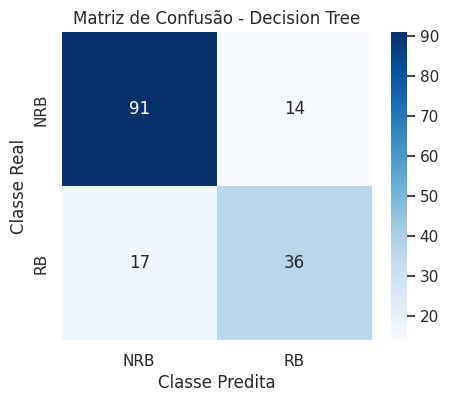


--- Treinando e Otimizando: KNN ---
Melhores Hiperparâmetros: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}

Relatório de Classificação no Conjunto de TESTE:
              precision    recall  f1-score   support

         NRB       0.93      0.85      0.89       105
          RB       0.74      0.87      0.80        53

    accuracy                           0.85       158
   macro avg       0.83      0.86      0.84       158
weighted avg       0.86      0.85      0.86       158



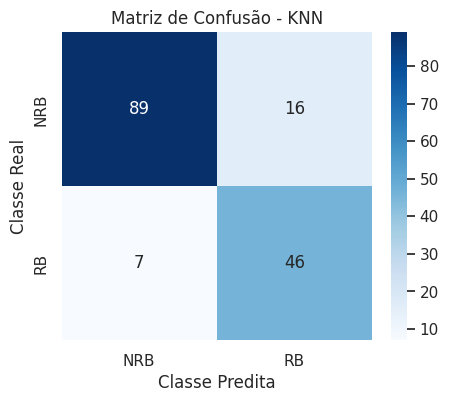


--- Treinando e Otimizando: Rede Neural (MLP) ---
Melhores Hiperparâmetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.01}

Relatório de Classificação no Conjunto de TESTE:
              precision    recall  f1-score   support

         NRB       0.89      0.90      0.89       105
          RB       0.79      0.77      0.78        53

    accuracy                           0.85       158
   macro avg       0.84      0.83      0.84       158
weighted avg       0.85      0.85      0.85       158



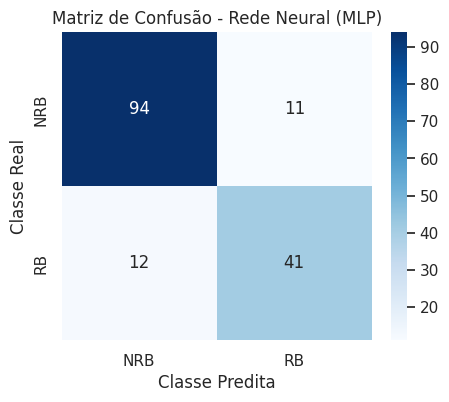

In [ ]:
# 1. Decision Tree
param_dt = {'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, 15, 20, None],
            'min_samples_split': [2, 5, 10, 20], 'min_samples_leaf': [1, 5, 10], 'class_weight': [None, 'balanced']}
dt_model = avaliar_modelo("Decision Tree", DecisionTreeClassifier(random_state=42), param_dt)

# 2. KNN
param_knn = {'n_neighbors': [3, 5, 7, 9, 11, 15, 19], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}
knn_model = avaliar_modelo("KNN", KNeighborsClassifier(), param_knn)

# 3. Rede Neural (MLP)
param_mlp = {'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
             'activation': ['relu', 'tanh', 'logistic'], 'alpha': [0.0001, 0.001, 0.01, 0.1], 'learning_rate_init': [0.001, 0.01]}
mlp_model = avaliar_modelo("Rede Neural (MLP)", MLPClassifier(max_iter=1000, random_state=42, early_stopping=False), param_mlp)

## 7. Modelagem Não Supervisionada (K-Means)
Vamos esquecer temporariamente os rótulos originais (`y`) e verificar como os dados moleculares se agrupam naturalmente. Usaremos toda a base padronizada (`X_scaled`).

Conforme especificado, iteraremos com $K$ variando de 2 a 10 e utilizaremos duas abordagens em conjunto para decidir o melhor $K$:
1. **Método do Cotovelo (Inércia / WCSS):** Busca o ponto onde a adição de novos clusters deixa de reduzir significativamente a variância interna.
2. **Silhouette Score:** Mede o quão similar um objeto é ao seu próprio cluster em comparação com outros clusters (varia de -1 a 1, sendo quanto mais próximo de 1, melhor).

--- Preparando Dataset Exclusivo para K-Means ---
Dimensões do dataset após limpeza global: (699, 20)
Nota: Dataset pronto, contendo as Top 20 features, normalizado e 100% livre de outliers.



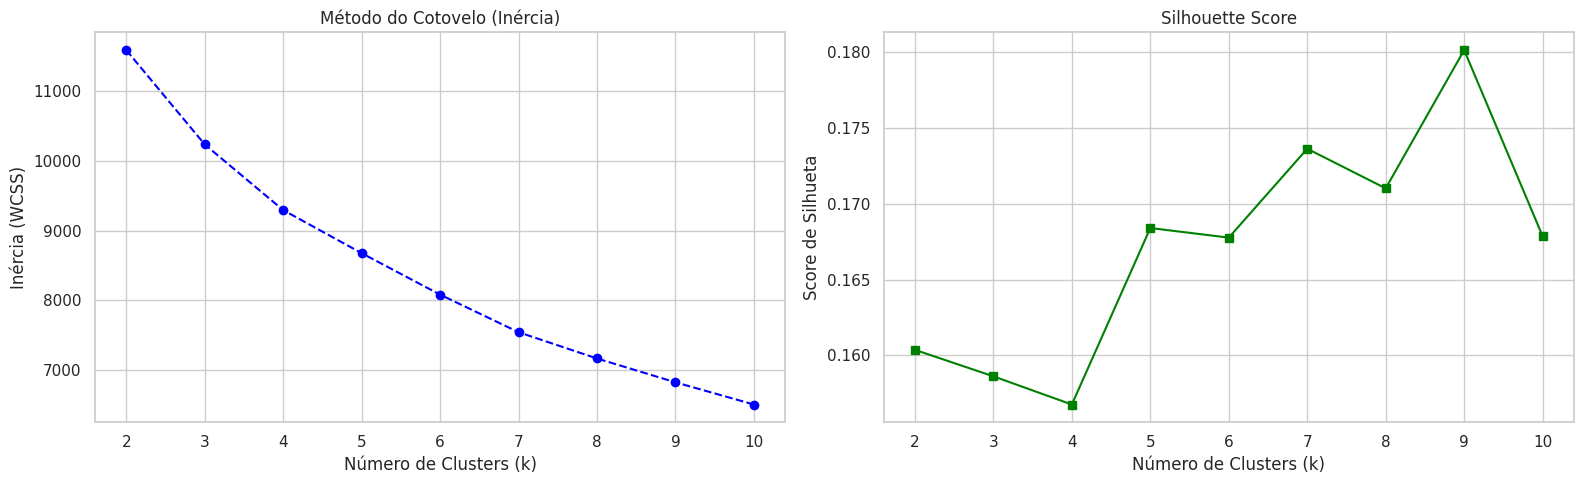

In [ ]:
# =====================================================================
# PREPARAÇÃO EXCLUSIVA PARA O K-MEANS
# =====================================================================
print("--- Preparando Dataset Exclusivo para K-Means ---")

# 1. Remoção de Outliers (Apenas para a Trilha Não Supervisionada)
iso_kmeans = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
outliers_kmeans = iso_kmeans.fit_predict(X_train_20)

# Filtrando os inliers (dados normais)
mask_kmeans_inliers = (outliers_kmeans == 1)
X_kmeans_clean = X_train_20[mask_kmeans_inliers]
y_kmeans_clean = y_train[mask_kmeans_inliers]

# 2. Normalização (Z-Score) do Dataset Global Limpo
scaler_kmeans = StandardScaler()
X_kmeans = pd.DataFrame(scaler_kmeans.fit_transform(X_kmeans_clean), columns=top_20)

print(f"Dimensões do dataset após limpeza global: {X_kmeans.shape}")
print("Nota: Dataset pronto, contendo as Top 20 features, normalizado e 100% livre de outliers.\n")

# =====================================================================
# EXECUÇÃO DO K-MEANS (Cotovelo e Silhouette)
# =====================================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    # Usamos o X_kmeans limpo!
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_kmeans)

    inercia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_kmeans, kmeans.labels_))

# Plotando os gráficos (Método do Cotovelo e Silhouette)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(K_range, inercia, marker='o', color='blue', linestyle='--')
ax[0].set_title('Método do Cotovelo (Inércia)')
ax[0].set_xlabel('Número de Clusters (k)')
ax[0].set_ylabel('Inércia (WCSS)')
ax[0].set_xticks(K_range)

ax[1].plot(K_range, silhouette_scores, marker='s', color='green', linestyle='-')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Número de Clusters (k)')
ax[1].set_ylabel('Score de Silhueta')
ax[1].set_xticks(K_range)

plt.tight_layout()
plt.show()

### Análise e Execução do Melhor K
Em problemas binários, frequentemente testamos `K=2` para ver se os clusters refletem as classes originais (RB e NRB). No entanto, deves inspecionar visualmente o Silhouette e o Cotovelo. Para fins didáticos e baseando-se no comportamento comum deste dataset, aplicaremos `K=2` e compararemos os clusters formados de forma não-supervisionada com os rótulos reais.

In [ ]:
# Supondo k ótimo (exemplo: k=2 baseado na semântica do problema ou nos gráficos)
melhor_k = 2
print(f"\nTreinando K-Means final com k={melhor_k}...")

kmeans_final = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
clusters_pred = kmeans_final.fit_predict(X_kmeans)

# Tabela de Contingência
df_comparacao = pd.DataFrame({
    'Classe_Real': label_encoder.inverse_transform(y_kmeans_clean),
    'Cluster_Atribuido': clusters_pred
})

crosstab = pd.crosstab(df_comparacao['Classe_Real'], df_comparacao['Cluster_Atribuido'],
                       rownames=['Classe Original'], colnames=['Cluster Encontrado'])
print("\nTabela de Contingência (Original vs Cluster):")
display(crosstab)

print("\nNota: Como o aprendizado é não-supervisionado, os rótulos do cluster (0 e 1) "
      "podem estar invertidos em relação aos rótulos originais. O que importa é a pureza "
      "de cada cluster (se ele isolou bem a maioria das instâncias RB de um lado e NRB do outro).")


Treinando K-Means final com k=2...

Tabela de Contingência (Original vs Cluster):


Cluster Encontrado,0,1
Classe Original,,
NRB,351,108
RB,86,154



Nota: Como o aprendizado é não-supervisionado, os rótulos do cluster (0 e 1) podem estar invertidos em relação aos rótulos originais. O que importa é a pureza de cada cluster (se ele isolou bem a maioria das instâncias RB de um lado e NRB do outro).


## 8. Visualização dos Clusters (Redução de Dimensionalidade com PCA)
O dataset possui 41 dimensões, o que impede a visualização direta. Usaremos a Análise de Componentes Principais (PCA) para comprimir as 41 features em 2 componentes e enxergar a distribuição espacial dos clusters formados pelo K-Means.

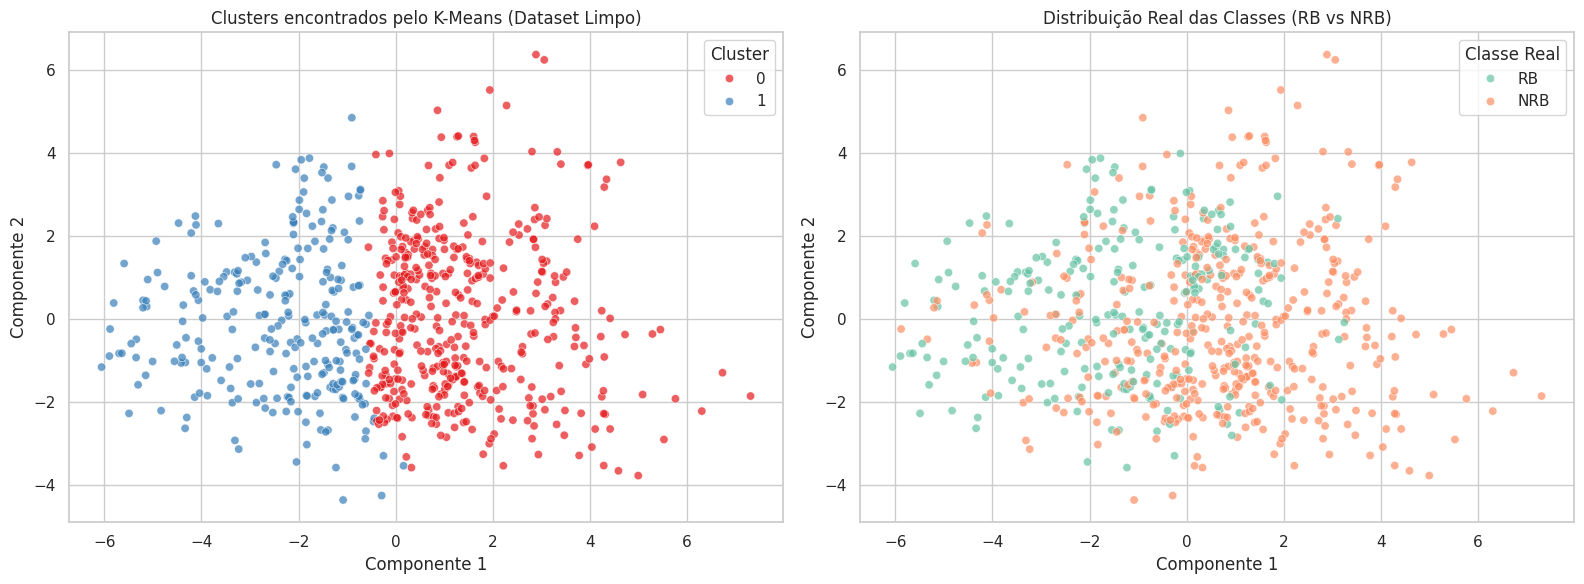

Variância explicada pelos 2 componentes: 44.37%


In [ ]:
from sklearn.decomposition import PCA

# Aplicando PCA para reduzir para 2 dimensões (usando X_kmeans)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_kmeans)
df_pca = pd.DataFrame(data = X_pca, columns = ['Componente 1', 'Componente 2'])
df_pca['Cluster'] = clusters_pred
df_pca['Classe Real'] = label_encoder.inverse_transform(y_kmeans_clean)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x='Componente 1', y='Componente 2', hue='Cluster', palette='Set1', data=df_pca, ax=ax[0], alpha=0.7)
ax[0].set_title('Clusters encontrados pelo K-Means (Dataset Limpo)')

sns.scatterplot(x='Componente 1', y='Componente 2', hue='Classe Real', palette='Set2', data=df_pca, ax=ax[1], alpha=0.7)
ax[1].set_title('Distribuição Real das Classes (RB vs NRB)')
plt.tight_layout()
plt.show()

print(f"Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%")